In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def read_imgs(left_pth, right_pth):
    left = cv2.imread(left_pth)
    right = cv2.imread(right_pth)
    
    left = cv2.cvtColor(left, cv2.COLOR_BGR2GRAY)
    right = cv2.cvtColor(right, cv2.COLOR_BGR2GRAY)
    plt.figure(figsize=(12, 6))
    
    plt.subplot(1,2,1)
    plt.imshow(left, 'gray')
    plt.title('Left')
    plt.axis('off')
    
    plt.subplot(1,2,2)
    plt.imshow(right, 'gray')
    plt.title('Right')
    plt.axis('off')
    
    plt.show()
    return left, right

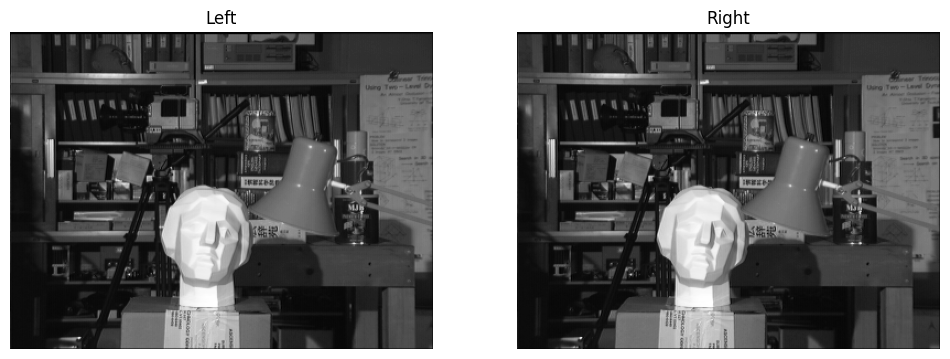

In [3]:
left_pth = '/kaggle/input/stereo-vision-dataset/tsukuba/scene1.row3.col1.ppm'
right_pth = '/kaggle/input/stereo-vision-dataset/tsukuba/scene1.row3.col2.ppm'
left, right = read_imgs(left_pth, right_pth)

In [4]:
def compute_disparity(left, right, window_size, method="SAD", max_disp=64):

    h, w = left.shape
    disparity = np.zeros((h, w), dtype=np.float32)
    half_window = window_size // 2
    
    for y in range(half_window, h-half_window):
        for x in range(half_window, w-half_window):
            L = left[y - half_window : y + half_window + 1,
                     x - half_window : x + half_window + 1]
            best_cost = np.inf
            best_disp = 0
            
            for d in range(max_disp):
                x_right = x - d
                if x_right - half_window < 0:
                    break
                    
                R = right[y - half_window : y + half_window + 1,
                          x_right - half_window : x_right + half_window + 1]

                if method == "SAD":
                    cost = np.sum(np.abs(L - R))
                else:
                    cost = np.sum((L - R) ** 2)

                if cost < best_cost:
                    best_cost = cost
                    best_disp = d

            disparity[y, x] = best_disp

    return disparity

Computing: SAD, window = 1
Computing: SSD, window = 1
Computing: SAD, window = 5
Computing: SSD, window = 5
Computing: SAD, window = 9
Computing: SSD, window = 9


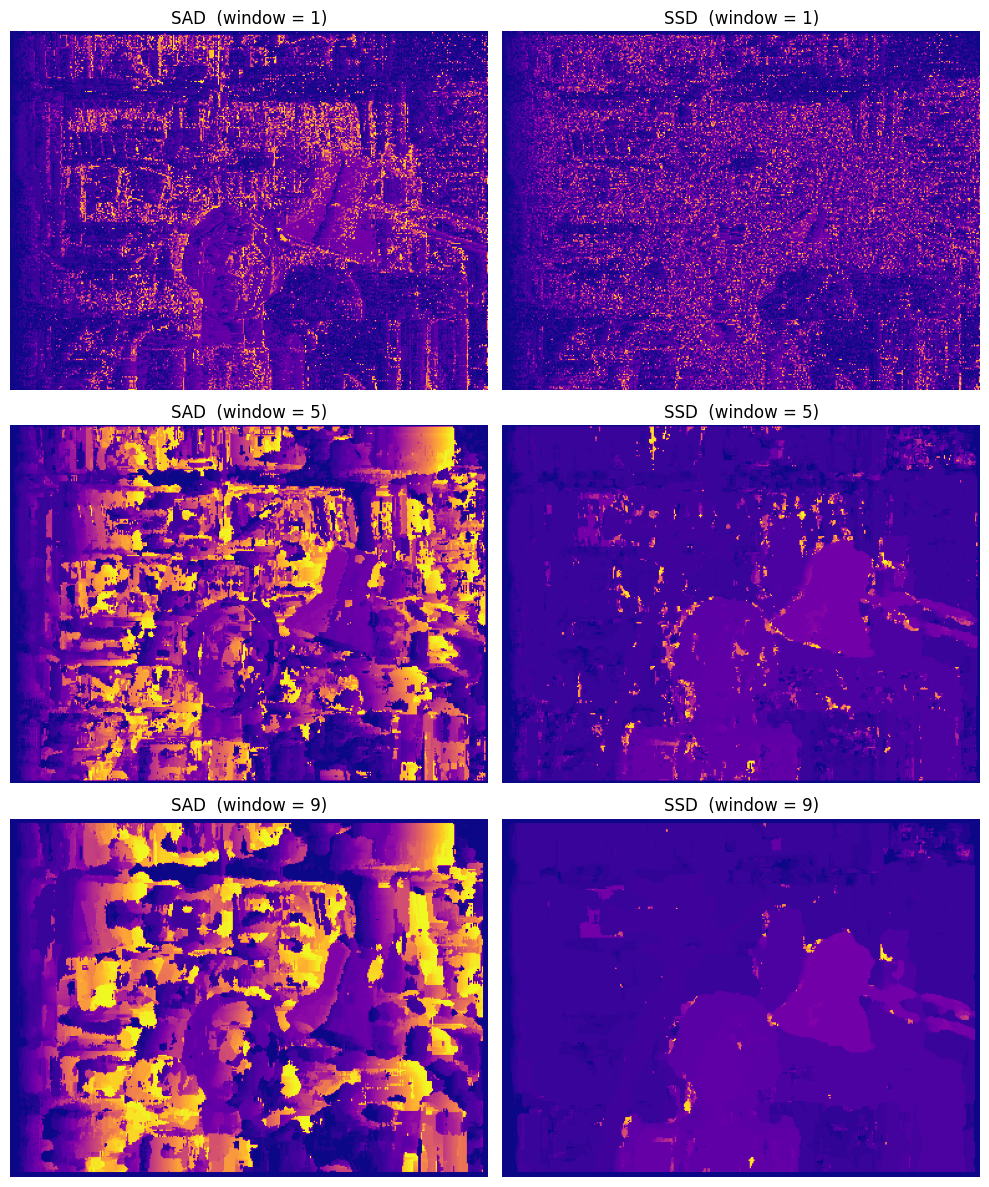

In [5]:
def compute_SD(left, right):
    window_sizes = [1, 5, 9]
    methods = ["SAD", "SSD"]
    results = {}
    
    for wsize in window_sizes:
        for m in methods:
            print(f"Computing: {m}, window = {wsize}")
            disp = compute_disparity(left, right, wsize, m)
            results[(m, wsize)] = disp
    
    plt.figure(figsize=(10, 12))
    i = 1
    for wsize in window_sizes:
        for m in methods:
            plt.subplot(3, 2, i)
            plt.imshow(results[(m, wsize)], cmap='plasma')
            plt.title(f"{m}  (window = {wsize})")
            plt.axis("off")
            i += 1
    
    plt.tight_layout()
    plt.show()

compute_SD(left, right)

In [6]:
sigma = 2.0
c0 = 1.0

def disparity_dp_scanline(Il, Ir):
    N = len(Il)
    dij = np.zeros((N+1, N+1), dtype=float)
    for i in range(1, N+1):
        for j in range(1, N+1):
            dij[i, j] = ((Il[i-1] - Ir[j-1]) ** 2) / (sigma ** 2)
            
    D = np.zeros((N+1, N+1), dtype=float)
    for i in range(N+1):
        D[i, 0] = i * c0        
    for j in range(N+1):
        D[0, j] = j * c0
        
    D[1,1] = dij[1,1]
    for i in range(1, N+1):
        for j in range(1, N+1):
            if i == 1 and j == 1:
                continue
            match_ = D[i-1, j-1] + dij[i, j]
            skip_left = D[i-1, j] + c0
            skip_right = D[i, j-1] + c0
            D[i, j] = min(match_, skip_left, skip_right)
    
    disp_left = np.zeros(N, dtype=int)
    disp_right = np.zeros(N, dtype=int)

    i = N
    j = N
    path_j = [j]
    path_i = [i]
    
    while i > 0 or j > 0:
        current = D[i, j]
        if i > 0 and j > 0 and abs(current - (D[i-1, j-1] + dij[i, j])) < 1e-6:
            d = abs(i - j)
            disp_left[i-1] = d
            disp_right[j-1] = d
            i -= 1
            j -= 1
        
        elif i > 0 and abs(current - (D[i-1, j] + c0)) < 1e-6:
            disp_left[i-1] = 0
            i -= 1

        else:
            disp_right[j-1] = 0
            j -= 1
        path_j.append(j)
        path_i.append(i)

    return disp_left, path_i, path_j
            

In [7]:
def disparity_dp_full(left_img, right_img):
    H, W = left_img.shape
    disparity = np.zeros((H, W), dtype=int)
    h = H // 2
    for r in range(H):
        Il = left_img[r, :].astype(float)
        Ir = right_img[r, :].astype(float)
        
        disp_row, _i, _j = disparity_dp_scanline(Il, Ir)
        if r == h:
            path_i = _i
            path_j = _j
            Il_ = Il
            Ir_ = Ir
        disparity[r, :] = disp_row

    return disparity, path_i, path_j, Il_, Ir_

disparity, path_j, path_i, Il_, Ir_ = disparity_dp_full(left, right)

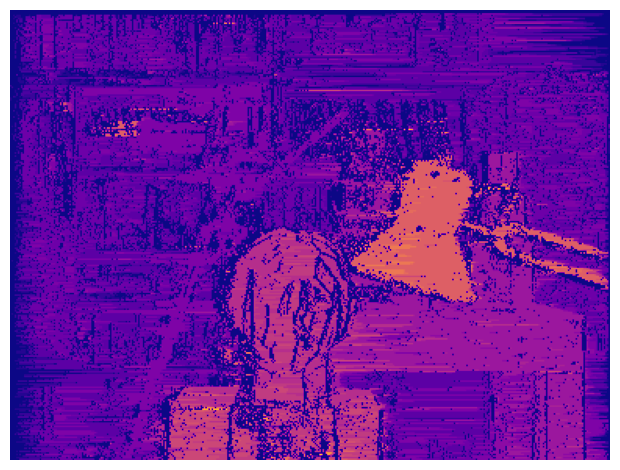

In [8]:
plt.imshow(disparity, cmap='plasma')
plt.axis("off")
plt.tight_layout()
plt.show()

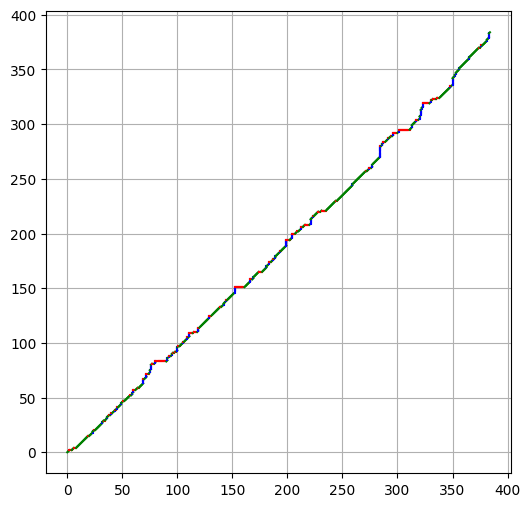

In [9]:
def plot_alignment(path_j, path_i, Il, Ir):  
    N = len(Il)
    path_j = path_j[::-1] 
    path_i = path_i[::-1]
    # print(path_x,path_y)
    # print("j: ",path_j)
    # print("i: ",path_i)
    plt.figure(figsize=(6,6))
    for k in range(1, len(path_j)):
        x0, y0 = path_j[k-1], path_i[k-1]
        x1, y1 = path_j[k], path_i[k]
        # print(k)
        # print("j0: ",x0)
        # print("j1: ",x1)
        # print("i0: ",y0)
        # print("i1: ",y1)
        
        if x1 == x0 and y1 != y0:
            plt.plot([x0, x1], [y0, y1], 'b')  # vertical line: left skipped
        elif y1 == y0 and x1 != x0:
            plt.plot([x0, x1], [y0, y1], 'r')  # horizontal line: right skipped
        else:
            plt.plot([x0, x1], [y0, y1], 'g')  # diagonal line: match

    # plt.scatter(range(N), Il, color='blue', label='Il (left scanline)')
    # plt.scatter(range(N), Ir, color='red', label='Ir (right scanline)')
    
    # plt.xlabel('Right scanline index (Ir)')
    # plt.ylabel('Left scanline index (Il)')
    # plt.title('DP Alignment Path')
    # plt.legend()
    plt.grid(True)
    plt.show()

plot_alignment(path_j, path_i, Il_, Ir_)

In [10]:
# disparity, path_i, path_j = disparity_dp_scanline(np.array([1, 2, 3]), np.array([5, 1, 2]))
# print(disparity)
# print(path_i)
# print(path_j)

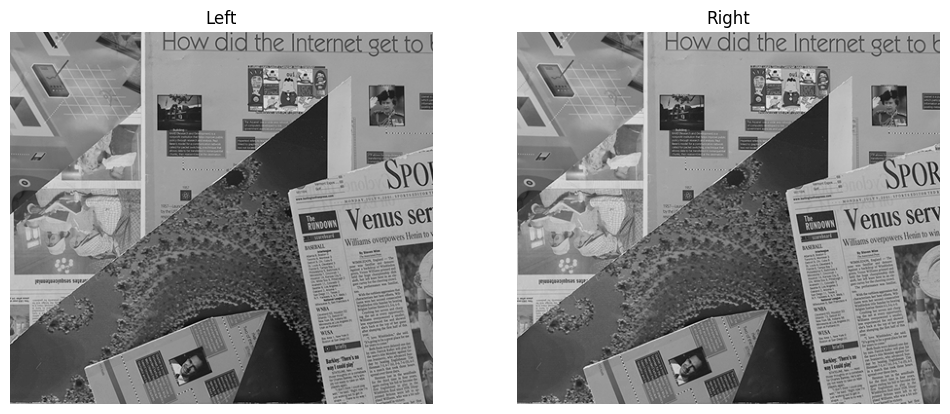

In [11]:
left_pth = '/kaggle/input/stereo-vision-dataset/poster/im0.ppm'
right_pth = '/kaggle/input/stereo-vision-dataset/poster/im2.ppm'
left, right = read_imgs(left_pth, right_pth)

Computing: SAD, window = 1
Computing: SSD, window = 1
Computing: SAD, window = 5
Computing: SSD, window = 5
Computing: SAD, window = 9
Computing: SSD, window = 9


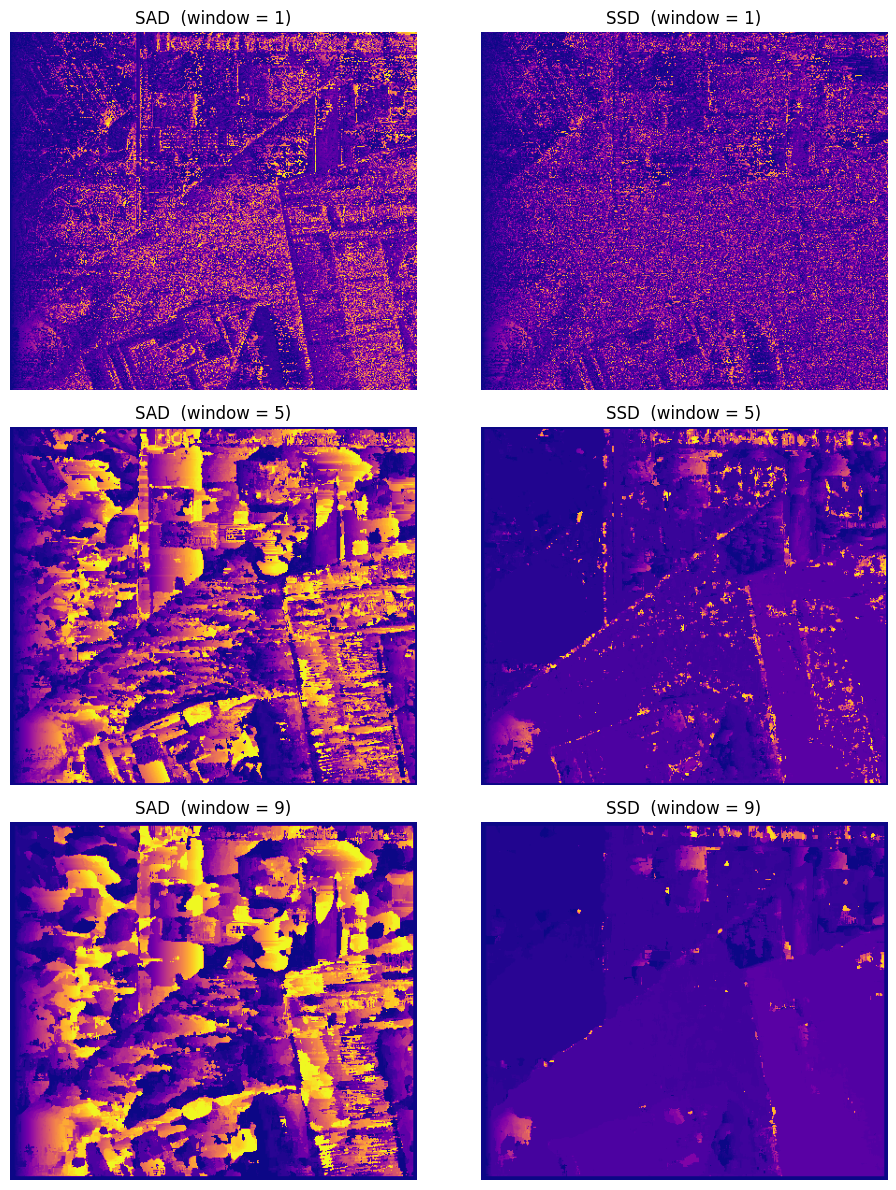

In [12]:
compute_SD(left, right)

In [13]:
disparity, path_j, path_i, Il_, Ir_ = disparity_dp_full(left, right)

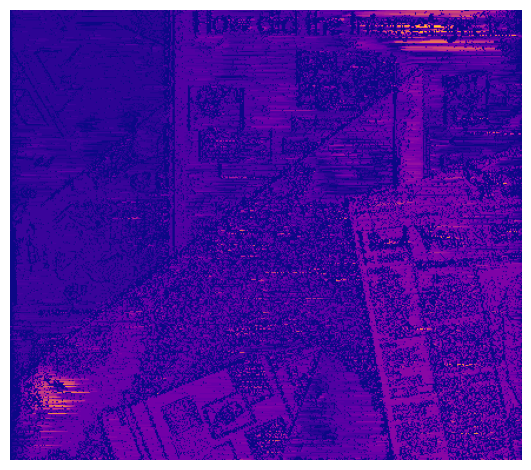

In [14]:
plt.imshow(disparity, cmap='plasma')
plt.axis("off")
plt.tight_layout()
plt.show()

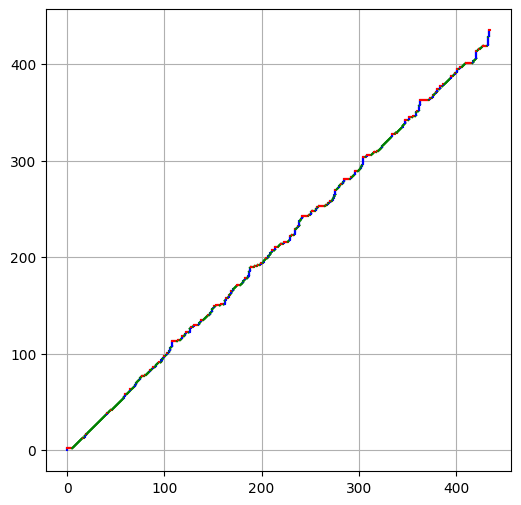

In [15]:
plot_alignment(path_j, path_i, Il_, Ir_)

In [18]:
disp_norm = cv2.normalize(disparity, None, 0, 255, cv2.NORM_MINMAX)
disp_norm = disp_norm.astype('uint8')
cv2.imwrite('/kaggle/working/Output_test.png', disp_norm)

True